These datasets are gathered from Coffee Quality Institute (CQI) in January, 2018.
I'm not the Owner of the Datasets, nor scrapping was performed by me. It was done in this GitHub's repo (kudos for the author), see there for further details.

In [26]:
import pandas as pd

df = pd.read_csv('merged_data_cleaned.csv')

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(df.shape)

print(df.isnull().sum().sort_values(ascending=False).head(5))

(1339, 43)
Lot.Number    1063
Farm.Name      359
Mill           318
Color          270
Producer       232
dtype: int64


In [27]:
df.describe()

,Number.of.Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Category.Two.Defects,altitude_low_meters,altitude_high_meters,altitude_mean_meters
count,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1338.000000,1339.000000,1109.000000,1109.000000,1109.000000
mean,154.182972,7.566706,7.520426,7.401083,7.535706,7.517498,7.518013,9.834877,9.835108,9.856692,7.503376,82.089851,0.088379,0.479462,0.173393,3.556385,1750.713315,1799.347775,1775.030545
std,129.987162,0.377560,0.398442,0.404463,0.379827,0.370064,0.408943,0.554591,0.763946,0.616102,0.473464,3.500575,0.048287,2.549683,0.832121,5.312541,8669.440545,8668.805771,8668.626080
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,14.000000,7.420000,7.330000,7.250000,7.330000,7.330000,7.330000,10.000000,10.000000,10.000000,7.250000,81.080000,0.090000,0.000000,0.000000,0.000000,1100.000000,1100.000000,1100.000000
50%,175.000000,7.580000,7.580000,7.420000,7.580000,7.500000,7.500000,10.000000,10.000000,10.000000,7.500000,82.500000,0.110000,0.000000,0.000000,2.000000,1310.640000,1350.000000,1310.640000
75%,275.000000,7.750000,7.750000,7.580000,7.750000,7.670000,7.750000,10.000000,10.000000,10.000000,7.750000,83.670000,0.120000,0.000000,0.000000,4.000000,1600.000000,1650.000000,1600.000000
max,1062.000000,8.750000,8.830000,8.670000,8.750000,8.580000,8.750000,10.000000,10.000000,10.000000,10.000000,90.580000,0.280000,63.000000,11.000000,55.000000,190164.000000,190164.000000,190164.000000


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Species                1339 non-null   object 
 1   Owner                  1332 non-null   object 
 2   Country.of.Origin      1338 non-null   object 
 3   Farm.Name              980 non-null    object 
 4   Lot.Number             276 non-null    object 
 5   Mill                   1021 non-null   object 
 6   ICO.Number             1180 non-null   object 
 7   Company                1130 non-null   object 
 8   Altitude               1113 non-null   object 
 9   Region                 1280 non-null   object 
 10  Producer               1107 non-null   object 
 11  Number.of.Bags         1339 non-null   int64  
 12  Bag.Weight             1339 non-null   object 
 13  In.Country.Partner     1339 non-null   object 
 14  Harvest.Year           1292 non-null   object 
 15  Grad

In [29]:
unique_countries_count = df['Country.of.Origin'].nunique()
print(f"Total number of unique countries: {unique_countries_count}")


top_10_countries = df['Country.of.Origin'].value_counts().head(10)
print("\nTop 10 Countries by frequency:")
print(top_10_countries)

Total number of unique countries: 36

Top 10 Countries by frequency:
Country.of.Origin
Mexico                          236
Colombia                        183
Guatemala                       181
Brazil                          132
Taiwan                           75
United States (Hawaii)           73
Honduras                         53
Costa Rica                       51
Ethiopia                         44
Tanzania, United Republic Of     40
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_26100\2123023650.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


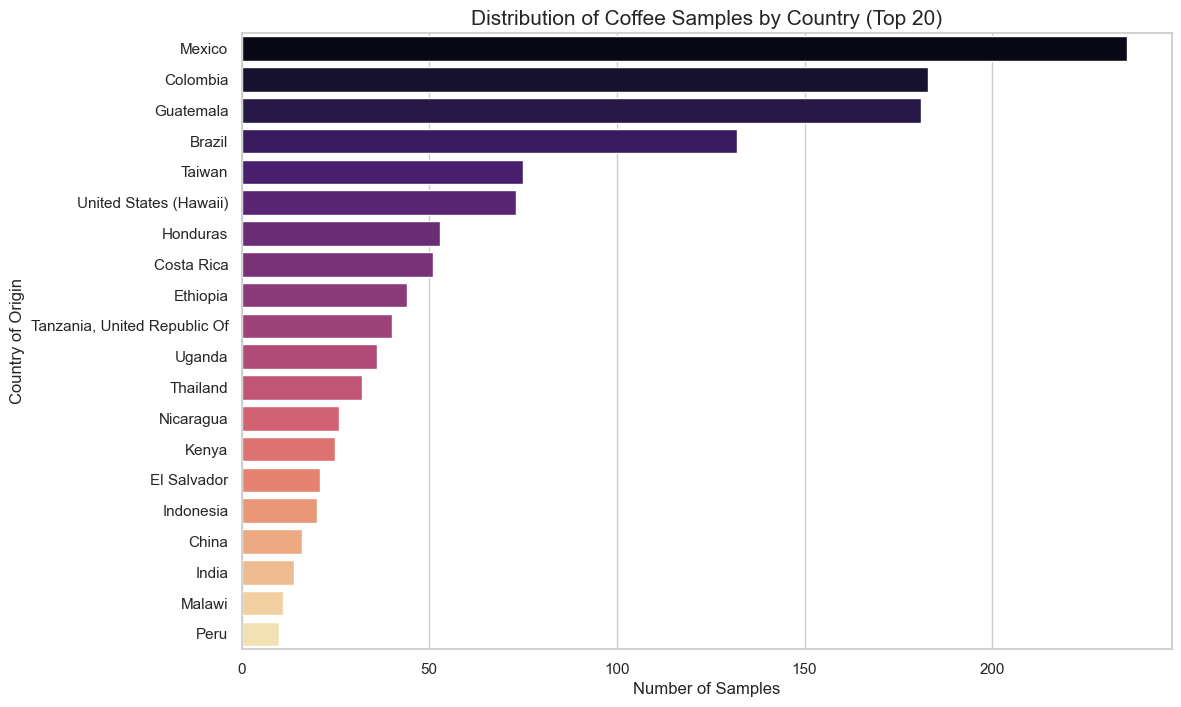

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

sns.countplot(
    data=df, 
    y='Country.of.Origin', 
    order=df['Country.of.Origin'].value_counts().iloc[:20].index,
    palette='magma'
)

plt.title('Distribution of Coffee Samples by Country (Top 20)', fontsize=15)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Country of Origin', fontsize=12)
plt.show()

In [31]:
unique_varieties = df['Variety'].nunique()
print(f"Total number of unique coffee varieties: {unique_varieties}")

top_varieties = df['Variety'].value_counts().head(10)
print("\nTop 10 Coffee Varieties in the dataset:")
print(top_varieties)

Total number of unique coffee varieties: 29

Top 10 Coffee Varieties in the dataset:
Variety
Caturra           256
Bourbon           226
Typica            211
Other             110
Catuai             74
Hawaiian Kona      44
Yellow Bourbon     35
Mundo Novo         33
Catimor            20
SL14               17
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_26100\2829769847.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


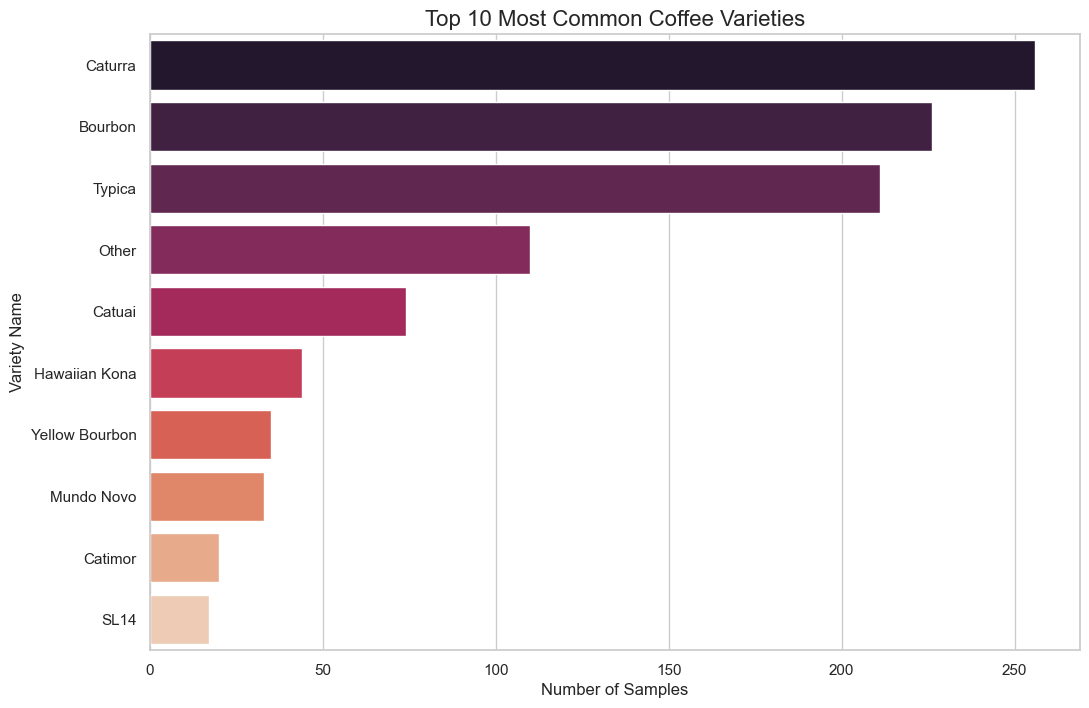

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_varieties.values, 
    y=top_varieties.index, 
    palette='rocket'
)

plt.title('Top 10 Most Common Coffee Varieties', fontsize=16)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Variety Name', fontsize=12)
plt.show()

In [33]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder

selected_columns = [
    'Species', 'Country.of.Origin', 'Variety', 'Color', 'Aroma', 'Flavor', 
    'Aftertaste', 'Acidity', 'Body', 'Balance', 'Moisture', 
    'altitude_mean_meters', 'Total.Cup.Points'
]
df_model = df[selected_columns].copy()
df_model['Color'] = df_model['Color'].fillna('Unknown')
df_model['Variety'] = df_model['Variety'].fillna('Unknown')
df_model['Country.of.Origin'] = df_model['Country.of.Origin'].fillna(df_model['Country.of.Origin'].mode()[0])
df_model['altitude_mean_meters'] = df_model['altitude_mean_meters'].fillna(df_model['altitude_mean_meters'].median())

In [34]:
le = LabelEncoder()
cols_to_label = ['Species', 'Country.of.Origin', 'Variety']

for col in cols_to_label:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model = pd.get_dummies(df_model, columns=['Color'], prefix='Color')

print("Encoding Completed! New Data Shape:", df_model.shape)
print(df_model.head())

Encoding Completed! New Data Shape: (1339, 16)
   Species  Country.of.Origin  Variety  Aroma  Flavor  Aftertaste  Acidity  \
0        0                  8       28   8.67    8.83        8.67     8.75   
1        0                  8       15   8.75    8.67        8.50     8.58   
2        0                  9        2   8.42    8.50        8.42     8.42   
3        0                  8       28   8.17    8.58        8.42     8.42   
4        0                  8       15   8.25    8.50        8.25     8.50   

   Body  Balance  Moisture  altitude_mean_meters  Total.Cup.Points  \
0  8.50     8.42      0.12                2075.0             90.58   
1  8.42     8.42      0.12                2075.0             89.92   
2  8.33     8.42      0.00                1700.0             89.75   
3  8.50     8.25      0.11                2000.0             89.00   
4  8.42     8.33      0.12                2075.0             88.83   

   Color_Blue-Green  Color_Bluish-Green  Color_Green  Color_Unk

C:\Users\DELL\AppData\Local\Temp\ipykernel_26100\378879914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Processing.Method', y='Total.Cup.Points', palette='Set2')


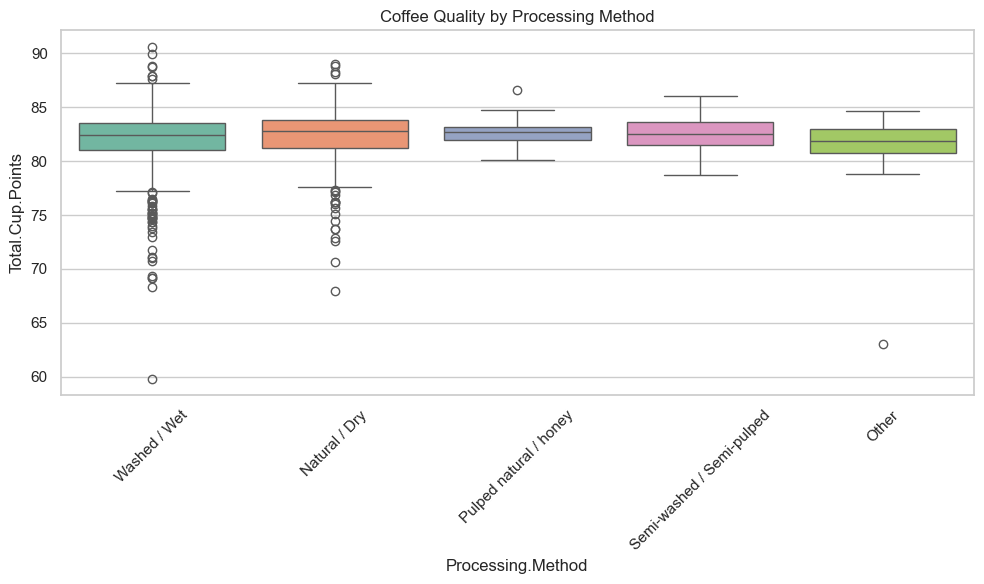

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Processing.Method', y='Total.Cup.Points', palette='Set2')
plt.title('Coffee Quality by Processing Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_1_processing.png')

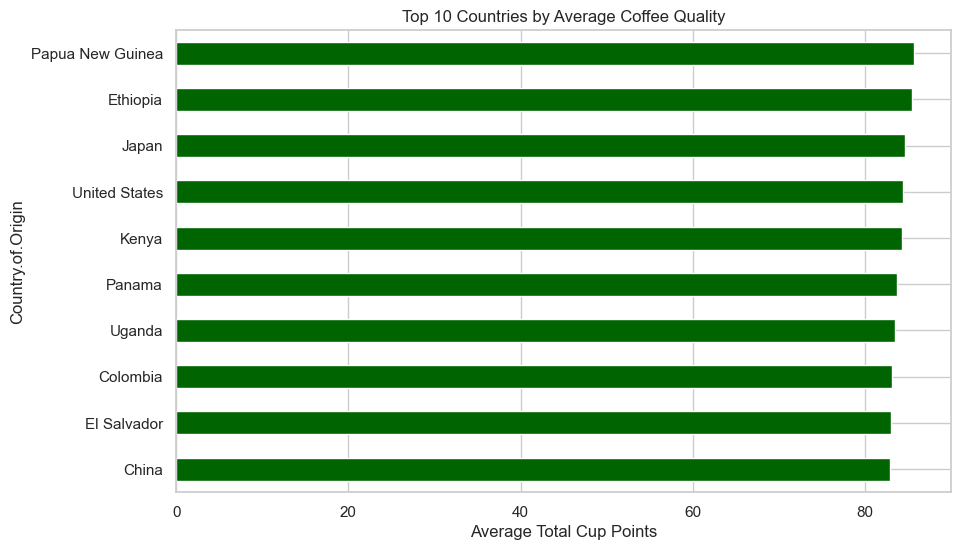

In [36]:
# 2. Top 10 Countries with highest average quality
top_quality_countries = df.groupby('Country.of.Origin')['Total.Cup.Points'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_quality_countries.plot(kind='barh', color='darkgreen')
plt.title('Top 10 Countries by Average Coffee Quality')
plt.xlabel('Average Total Cup Points')
plt.gca().invert_yaxis() # To show the highest on top
plt.show()

In [37]:
import pandas as pd

def classify_quality(score):
    if score < 80:
        return 0 
    elif score < 82.5:
        return 1  
    elif score < 85:
        return 2  
    else:
        return 3 

df_model['Quality_Level'] = df_model['Total.Cup.Points'].apply(classify_quality)

level_counts = df_model['Quality_Level'].value_counts().sort_index()
print("Distribution of Quality Levels:")
print(level_counts)

Distribution of Quality Levels:
Quality_Level
0    187
1    469
2    577
3    106
Name: count, dtype: int64


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

drop_cols = ['Total.Cup.Points', 'Quality_Level']
if 'Quality_Class' in df_model.columns:
    drop_cols.append('Quality_Class')

X = df_model.drop(columns=drop_cols)
y = df_model['Quality_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Overall Accuracy: {acc:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 76.12%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.72      0.75        40
           1       0.70      0.74      0.72        86
           2       0.82      0.80      0.81       122
           3       0.67      0.70      0.68        20

    accuracy                           0.76       268
   macro avg       0.74      0.74      0.74       268
weighted avg       0.76      0.76      0.76       268



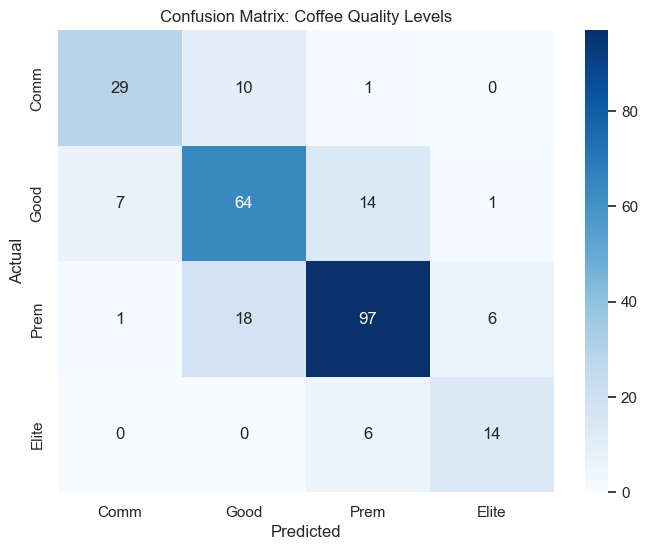

In [39]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Comm', 'Good', 'Prem', 'Elite'],
            yticklabels=['Comm', 'Good', 'Prem', 'Elite'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Coffee Quality Levels')
plt.show()

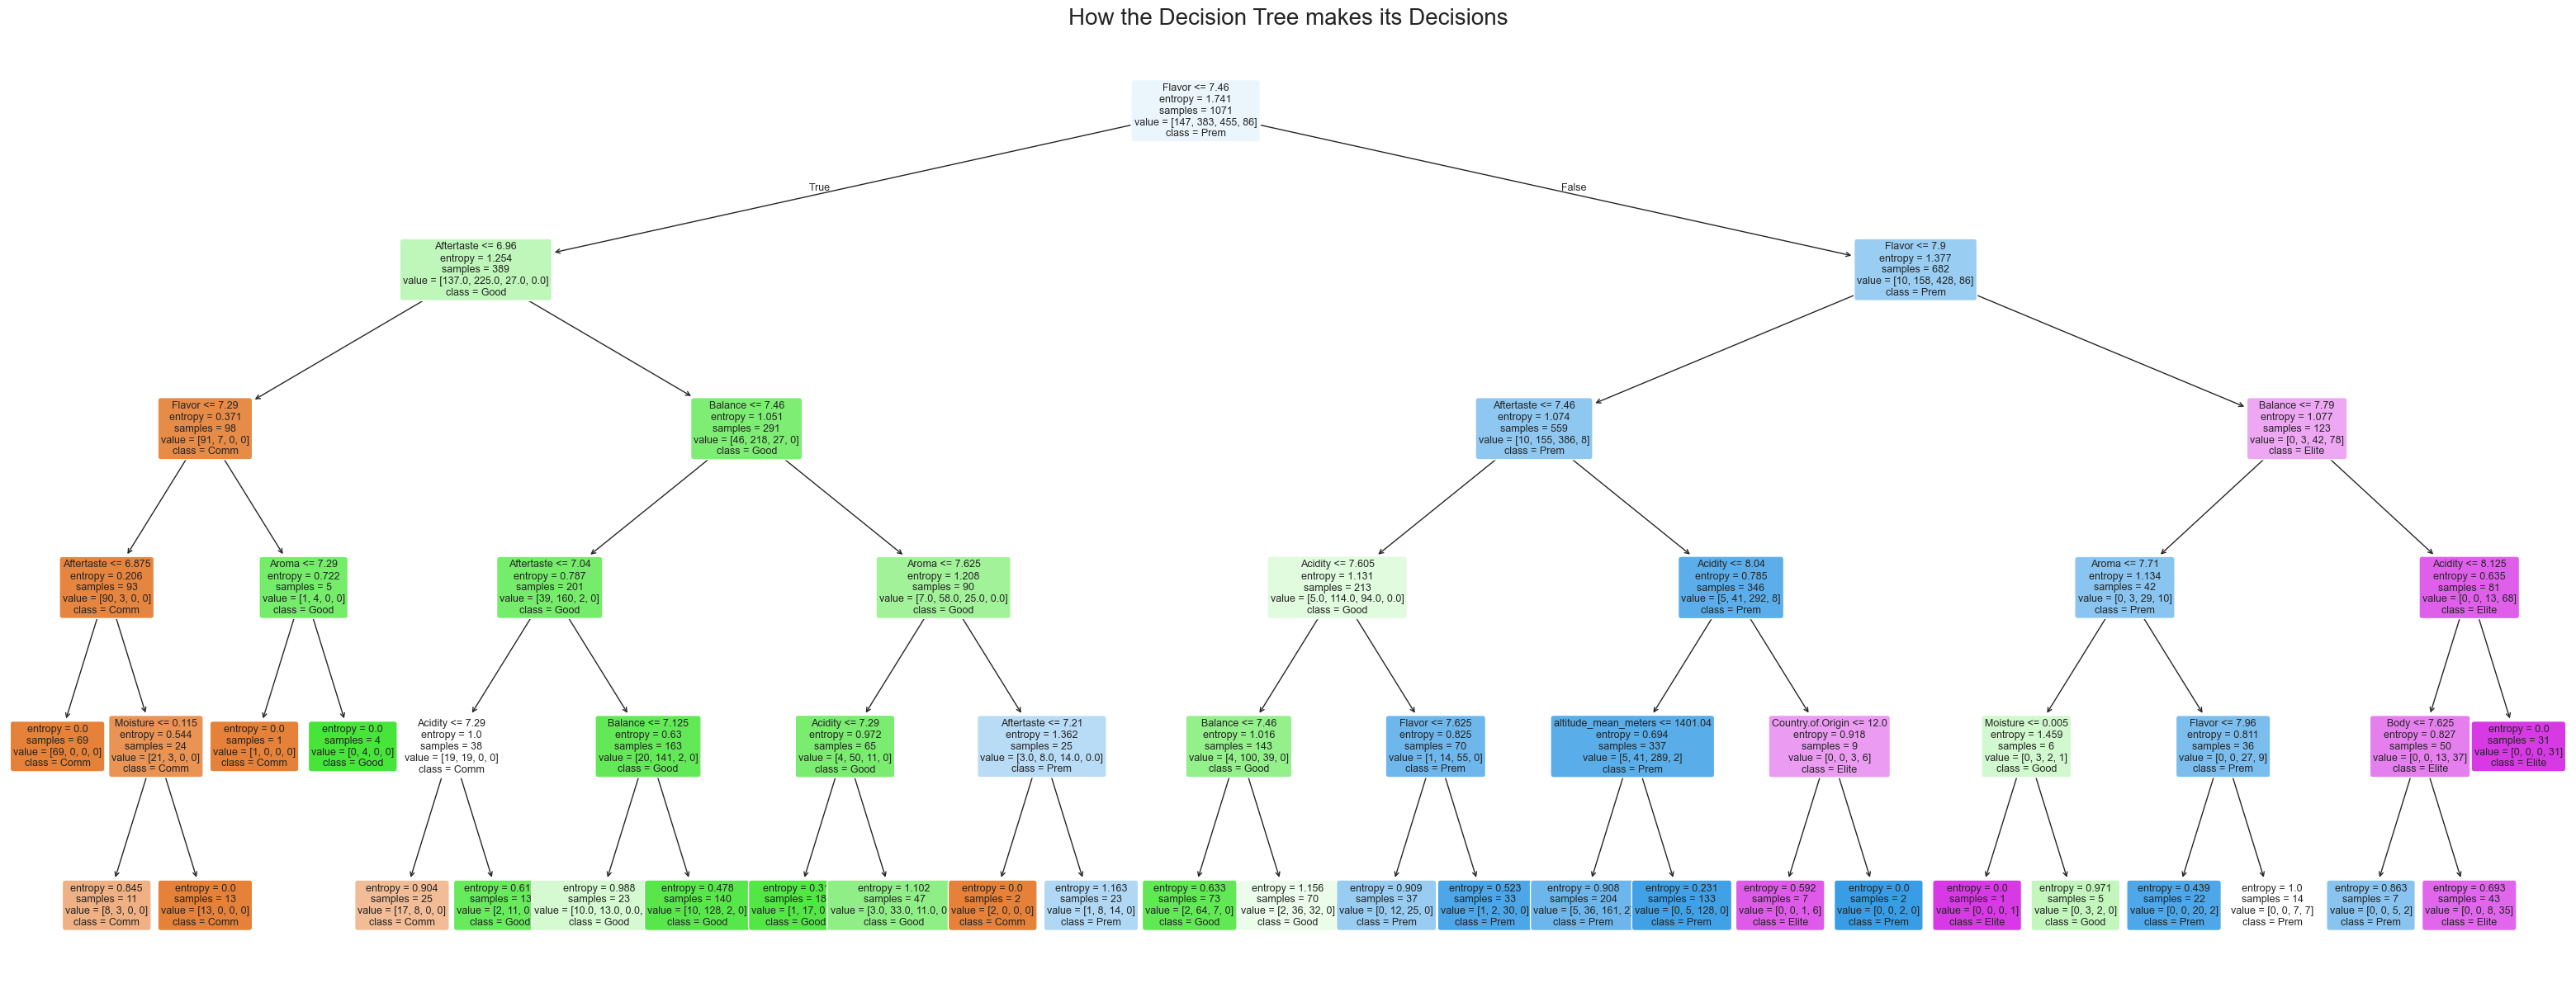

In [46]:
from sklearn.tree import plot_tree

plt.figure(figsize=(40, 15))
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['Comm', 'Good', 'Prem', 'Elite'], 
          filled=True, 
          rounded=True, 
          fontsize=9)
plt.title("How the Decision Tree makes its Decisions", fontsize=20)
plt.show()

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_acc:.2%}")
print("-" * 30)


Random Forest Accuracy: 82.46%
------------------------------


C:\Users\DELL\AppData\Local\Temp\ipykernel_26100\1132847101.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')


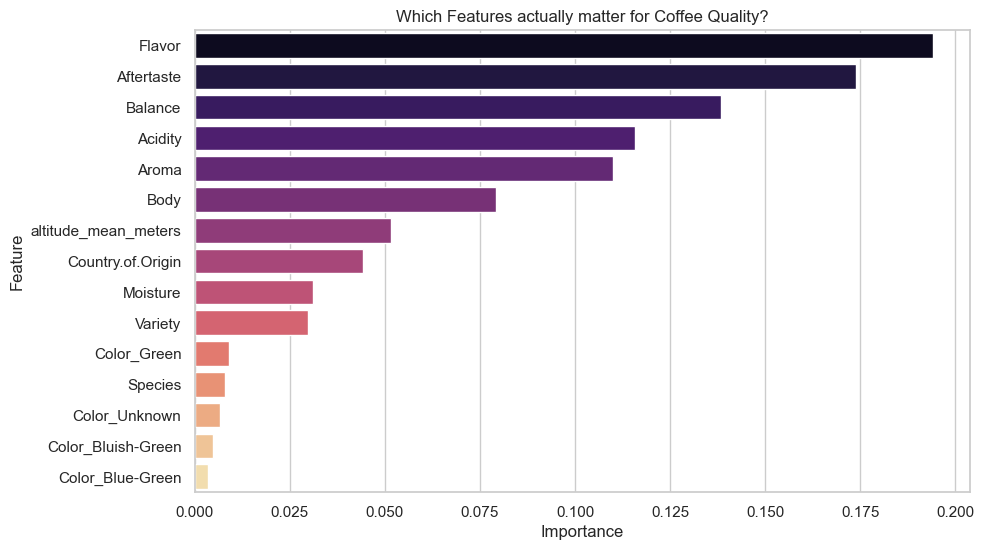

In [43]:
importances = rf_clf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Which Features actually matter for Coffee Quality?')
plt.show()

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],          
    'max_depth': [10, 20, None],               
    'min_samples_split': [2, 5, 10],           
    'criterion': ['gini', 'entropy']          
}
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score from Grid Search: {grid_search.best_score_:.2%}")

best_rf = grid_search.best_estimator_
final_predictions = best_rf.predict(X_test)
print(f"Final Accuracy on Test Set: {accuracy_score(y_test, final_predictions):.2%}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
Best Score from Grid Search: 85.34%
Final Accuracy on Test Set: 84.33%


In [47]:
import joblib

joblib.dump(best_rf, 'coffee_model.pkl')

model_columns = list(X_train.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("Files saved successfully.")

Files saved successfully.
